# MalthusJAX Level 2: Mutation Operators Demo

This notebook demonstrates the **mutation operator architecture** in MalthusJAX:
- **Binary mutations**: `BitFlipMutation`, `ScrambleMutation`, `SwapMutation`
- **Real mutations**: `GaussianMutation`, `BallMutation`, `PolynomialMutation`
- **3-Tier paradigm**: Separation of RNG logic from arithmetic kernels
- **Injection mode**: Alternative pattern for high-performance batch processing

Key concepts covered:
1. Mutation operator configuration and instantiation
2. Per-individual vs. population-level mutation
3. Key budgeting and resource management
4. Offspring generation and autocorrection
5. JAX integration (`jax.jit`, `jax.vmap`, XLA fusion)

In [68]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

from malthusjax.core.genome import (
    BinaryGenomeConfig,
    BinaryPopulation,
    RealGenome,
    RealGenomeConfig,
    RealPopulation,
)
from malthusjax.operators.mutation import (
    BallMutation,
    BitFlipMutation,
    GaussianMutation,
    GaussianMutation_injection,
    PolynomialMutation,
    ScrambleMutation,
    SwapMutation,
)

# Reproducibility
key = jr.PRNGKey(42)
print(f"JAX version: {jax.__version__}")
print(f"Devices: {jax.devices()}")

JAX version: 0.8.0
Devices: [CpuDevice(id=0)]


---
## 1. Binary Mutations

Binary mutations operate on bit-strings (0/1 sequences). They're essential for:
- Combinatorial optimization (knapsack, TSP)
- Feature selection
- Boolean satisfiability problems

In [69]:
BINARY_LENGTH = 20
POP_SIZE = 10

binary_config = BinaryGenomeConfig(shape=(BINARY_LENGTH,), p=0.5)
key, subkey = jr.split(key)
binary_pop = BinaryPopulation.init_random(subkey, binary_config, size=POP_SIZE)

print(f"Binary population size: {len(binary_pop)}")
print(f"Genome length: {BINARY_LENGTH}")
print(f"First individual: {binary_pop[0].values}")

Binary population size: 10
Genome length: 20
First individual: [1 0 0 1 1 1 0 0 0 0 0 0 1 0 0 1 1 0 1 0]


### 1.1 Bit Flip Mutation

The most basic binary mutation: independently flip each bit with probability `mutation_rate`.

In [70]:
# Create bit flip mutation operator
bit_flip = BitFlipMutation(
    num_offspring=2,
    mutation_rate=0.1,  # 10% chance per bit
    input_length=POP_SIZE,
)

print(f"Mutation rate: {bit_flip.mutation_rate}")
print(f"Offspring per parent: {bit_flip.num_offspring}")
print(f"Keys per operation: {bit_flip.num_keys_per_atomic_operation}")

Mutation rate: 0.1
Offspring per parent: 2
Keys per operation: 1


In [71]:
# Apply bit flip mutation
key, subkey = jr.split(key)
num_keys = bit_flip.num_keys(binary_pop.genes.values.shape)
mutation_keys = jr.split(subkey, num_keys)

print(f"Required keys: {num_keys}")
print(f"Keys shape: {mutation_keys.shape}")

# Mutate population
mutated_pop = bit_flip(mutation_keys, binary_pop, binary_config)

print(f"\nOriginal population size: {len(binary_pop)}")
print(f"Mutated population size: {len(mutated_pop)}")
print(f"Expected size: {POP_SIZE * bit_flip.num_offspring}")

Required keys: 20
Keys shape: (20, 2)

Original population size: 10
Mutated population size: 20
Expected size: 20


In [72]:
# Compare parent vs offspring
parent_idx = 0
parent = binary_pop[parent_idx]
offspring1 = mutated_pop[parent_idx * 2]
offspring2 = mutated_pop[parent_idx * 2 + 1]

print(f"Parent:     {parent.values}")
print(f"Offspring1: {offspring1.values}")
print(f"Offspring2: {offspring2.values}")

# Count mutations
diff1 = jnp.sum(parent.values != offspring1.values)
diff2 = jnp.sum(parent.values != offspring2.values)

print(f"\nBits flipped in offspring1: {diff1}/{BINARY_LENGTH} ({diff1 / BINARY_LENGTH:.1%})")
print(f"Bits flipped in offspring2: {diff2}/{BINARY_LENGTH} ({diff2 / BINARY_LENGTH:.1%})")
print(f"Expected rate: {bit_flip.mutation_rate:.1%}")

Parent:     [1 0 0 1 1 1 0 0 0 0 0 0 1 0 0 1 1 0 1 0]
Offspring1: [1 0 0 1 1 1 1 0 0 0 0 0 1 0 0 1 1 0 1 0]
Offspring2: [1 1 0 1 1 1 0 0 0 0 0 0 1 0 0 1 1 0 1 0]

Bits flipped in offspring1: 1/20 (5.0%)
Bits flipped in offspring2: 1/20 (5.0%)
Expected rate: 10.0%


In [73]:
key, subkey = jr.split(key)

# Generate the flip mask (Tier 2)
mask = bit_flip._generate_noise([subkey], binary_config)
print("Generated flip mask:", mask)

# Apply the arithmetic kernel to a single genome (Tier 1)
parent = binary_pop[0]
mutant = bit_flip._mutate_one(parent, mask, binary_config)
print("Parent: ", parent.values)
print("Mutant:  ", mutant.values)
print("Bits flipped:", int(jnp.sum(parent.values != mutant.values)))

Generated flip mask: [False False False  True False False False False False False False False
 False False False False False False False  True]
Parent:  [1 0 0 1 1 1 0 0 0 0 0 0 1 0 0 1 1 0 1 0]
Mutant:   [1 0 0 0 1 1 0 0 0 0 0 0 1 0 0 1 1 0 1 1]
Bits flipped: 2


### 1.2 Scramble Mutation

Randomly permutes the entire bit-string with probability `mutation_rate`.

In [74]:
# Create scramble mutation operator
scramble_mut = ScrambleMutation(
    num_offspring=1,
    mutation_rate=1.0,  # 50% chance to scramble
    input_length=POP_SIZE,
)

# Apply scramble mutation
key, subkey = jr.split(key)
num_keys = scramble_mut.num_keys(binary_pop.genes.values.shape)
scramble_keys = jr.split(subkey, num_keys)

scrambled_pop = scramble_mut(scramble_keys, binary_pop, binary_config)

print("Scramble mutation applied!")
print(f"Keys per operation: {scramble_mut.num_keys_per_atomic_operation}")
print(f"Total keys used: {len(scramble_keys)}")

Scramble mutation applied!
Keys per operation: 2
Total keys used: 20


In [75]:
# Compare original vs scrambled
for i in range(3):
    original = binary_pop[i]
    scrambled = scrambled_pop[i]

    # Check if scrambling occurred (different order, same content)
    same_content = jnp.sum(original.values) == jnp.sum(scrambled.values)
    same_order = jnp.array_equal(original.values, scrambled.values)

    print(f"Individual {i}:")
    print(f"  Original:  {original.values}")
    print(f"  Scrambled: {scrambled.values}")
    print(f"  Same content: {same_content}, Same order: {same_order}")
    print()

Individual 0:
  Original:  [1 0 0 1 1 1 0 0 0 0 0 0 1 0 0 1 1 0 1 0]
  Scrambled: [0 0 0 0 0 0 1 1 0 1 1 0 0 0 1 1 0 1 0 1]
  Same content: True, Same order: False

Individual 1:
  Original:  [1 0 1 0 1 1 0 1 0 1 1 1 1 0 0 1 1 1 1 1]
  Scrambled: [0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1]
  Same content: True, Same order: False

Individual 2:
  Original:  [0 0 0 1 1 1 0 0 0 0 0 1 1 1 0 0 1 1 0 0]
  Scrambled: [0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 1 1 1 0 1]
  Same content: True, Same order: False



### 1.3 Swap Mutation

Randomly swaps two positions in the bit-string with probability `mutation_rate`.

In [76]:
# Create swap mutation operator
swap_mut = SwapMutation(
    num_offspring=1,
    mutation_rate=0.8,  # 80% chance to swap
    input_length=POP_SIZE,
)

# Apply swap mutation
key, subkey = jr.split(key)
num_keys = swap_mut.num_keys(binary_pop.genes.values.shape)
swap_keys = jr.split(subkey, num_keys)

swapped_pop = swap_mut(swap_keys, binary_pop, binary_config)

print("Swap mutation applied!")
print(f"Keys per operation: {swap_mut.num_keys_per_atomic_operation}")

Swap mutation applied!
Keys per operation: 3


In [77]:
# Analyze swap mutations
for i in range(3):
    original = binary_pop[i]
    swapped = swapped_pop[i]

    # Find differences
    diff_positions = jnp.where(original.values != swapped.values)[0]

    print(f"Individual {i}:")
    print(f"  Original: {original.values}")
    print(f"  Swapped:  {swapped.values}")
    print(f"  Differences at positions: {diff_positions}")
    print()

Individual 0:
  Original: [1 0 0 1 1 1 0 0 0 0 0 0 1 0 0 1 1 0 1 0]
  Swapped:  [1 0 0 1 1 1 0 0 0 0 0 0 1 0 0 1 1 0 1 0]
  Differences at positions: []

Individual 1:
  Original: [1 0 1 0 1 1 0 1 0 1 1 1 1 0 0 1 1 1 1 1]
  Swapped:  [1 0 1 0 1 1 0 1 0 1 1 1 1 0 0 1 1 1 1 1]
  Differences at positions: []

Individual 2:
  Original: [0 0 0 1 1 1 0 0 0 0 0 1 1 1 0 0 1 1 0 0]
  Swapped:  [0 0 1 1 0 1 0 0 0 0 0 1 1 1 0 0 1 1 0 0]
  Differences at positions: [2 4]



---
## 2. Real-Valued Mutations

Real-valued mutations add noise to continuous parameters. Essential for:
- Function optimization
- Neural network evolution
- Parameter tuning

In [78]:
# Create a real-valued population for testing
DIMS = 5
real_config = RealGenomeConfig(shape=(DIMS,), bounds=(-5.0, 5.0))
key, subkey = jr.split(key)
real_pop = RealPopulation.init_random(subkey, real_config, size=POP_SIZE)

print(f"Real population size: {len(real_pop)}")
print(f"Dimensions: {DIMS}")
print(f"Bounds: {real_config.bounds}")
print(f"First individual: {real_pop[0].values}")

Real population size: 10
Dimensions: 5
Bounds: (-5.0, 5.0)
First individual: [-2.7015471  1.9166839 -2.341901   2.6928997 -3.56426  ]


### 2.1 Gaussian Mutation

Adds Gaussian (normal) noise to each component independently.

In [79]:
# Create Gaussian mutation operator
gaussian_mut = GaussianMutation(
    num_offspring=3,
    mutation_rate=0.8,  # 80% of components mutated
    mutation_strength=0.5,  # Standard deviation of noise
    clip=True,  # Respect bounds
    input_length=POP_SIZE,
)

print(f"Mutation rate: {gaussian_mut.mutation_rate}")
print(f"Mutation strength (σ): {gaussian_mut.mutation_strength}")
print(f"Clipping enabled: {gaussian_mut.clip}")
print(f"Keys per operation: {gaussian_mut.num_keys_per_atomic_operation}")

Mutation rate: 0.8
Mutation strength (σ): 0.5
Clipping enabled: True
Keys per operation: 2


In [80]:
# Apply Gaussian mutation
key, subkey = jr.split(key)
num_keys = gaussian_mut.num_keys(real_pop.genes.values.shape)
gaussian_keys = jr.split(subkey, num_keys)

gaussian_pop = gaussian_mut(gaussian_keys, real_pop, real_config)

print("Gaussian mutation applied!")
print(f"Total keys used: {len(gaussian_keys)}")
print(f"Offspring population size: {len(gaussian_pop)}")

Gaussian mutation applied!
Total keys used: 60
Offspring population size: 30


In [81]:
# Analyze Gaussian mutations
parent_idx = 0
parent = real_pop[parent_idx]

print(f"Parent {parent_idx}: {parent.values}")
print("Offspring:")

for i in range(gaussian_mut.num_offspring):
    offspring = gaussian_pop[parent_idx * gaussian_mut.num_offspring + i]

    # Calculate changes
    delta = offspring.values - parent.values
    mutation_mask = jnp.abs(delta) > 1e-6  # Detect which components were mutated

    print(f"  Offspring {i}: {offspring.values}")
    print(f"    Δ: {delta}")
    print(f"    Mutated components: {jnp.sum(mutation_mask)}/{DIMS}")
    print()

Parent 0: [-2.7015471  1.9166839 -2.341901   2.6928997 -3.56426  ]
Offspring:
  Offspring 0: [-2.5868344  2.0112505 -2.4397032  2.7002585 -3.5848584]
    Δ: [ 0.11471272  0.09456658 -0.09780216  0.00735879 -0.02059841]
    Mutated components: 5/5

  Offspring 1: [-2.6090322  1.9166839 -2.5502367  2.8481827 -3.2338371]
    Δ: [ 0.09251499  0.         -0.20833564  0.15528297  0.33042288]
    Mutated components: 4/5

  Offspring 2: [-2.633181   1.9166839 -1.8801204  2.6928997 -4.1323853]
    Δ: [ 0.06836605  0.          0.46178067  0.         -0.56812525]
    Mutated components: 3/5



In [82]:
key, subkey = jr.split(key)
k_mask, k_noise = jr.split(subkey, 2)

# Generate the delta payload (Tier 2)
noise_payload = gaussian_mut._generate_noise([k_mask, k_noise], real_config)
print("Noise payload:", noise_payload)
print(
    "Noise stats: mean={:.6f}, std={:.6f}".format(
        float(jnp.mean(noise_payload)), float(jnp.std(noise_payload))
    )
)

# Apply the arithmetic kernel to a single real genome (Tier 1)
parent_real = real_pop[0]
mutant_real = gaussian_mut._mutate_one(parent_real, noise_payload, real_config)
print("Parent: ", parent_real.values)
print("Mutant:  ", mutant_real.values)
print("Mutated components:", int(jnp.sum(jnp.abs(noise_payload) > 1e-6)))

Noise payload: [-0.         -0.41417825 -0.4605289   0.13285059 -0.16581503]
Noise stats: mean=-0.181534, std=0.229783
Parent:  [-2.7015471  1.9166839 -2.341901   2.6928997 -3.56426  ]
Mutant:   [-2.7015471  1.5025057 -2.80243    2.8257504 -3.7300751]
Mutated components: 4


### 2.2 Ball Mutation

Samples uniformly within an n-dimensional ball (sphere) of given radius.
Maintains rotational invariance and ensures uniform density.

In [83]:
# Create Ball mutation operator
ball_mut = BallMutation(
    num_offspring=2,
    radius=1.0,  # Ball radius
    mutation_rate=0.6,  # 60% chance to mutate
    clip=True,
    input_length=POP_SIZE,
)

# Apply Ball mutation
key, subkey = jr.split(key)
num_keys = ball_mut.num_keys(real_pop.genes.values.shape)
ball_keys = jr.split(subkey, num_keys)

ball_pop = ball_mut(ball_keys, real_pop, real_config)

print("Ball mutation applied!")
print(f"Radius: {ball_mut.radius}")
print(f"Keys per operation: {ball_mut.num_keys_per_atomic_operation}")

Ball mutation applied!
Radius: 1.0
Keys per operation: 3


In [84]:
# Analyze Ball mutations - check if deltas are within ball
parent_idx = 0
parent = real_pop[parent_idx]

print(f"Parent {parent_idx}: {parent.values}")
print("Ball mutation offspring:")

for i in range(ball_mut.num_offspring):
    offspring = ball_pop[parent_idx * ball_mut.num_offspring + i]

    delta = offspring.values - parent.values
    delta_magnitude = jnp.sqrt(jnp.sum(delta**2))

    print(f"  Offspring {i}: {offspring.values}")
    print(f"    Δ magnitude: {delta_magnitude:.4f} (max: {ball_mut.radius})")
    print(f"    Within ball: {delta_magnitude <= ball_mut.radius + 1e-6}")
    print()

Parent 0: [-2.7015471  1.9166839 -2.341901   2.6928997 -3.56426  ]
Ball mutation offspring:
  Offspring 0: [-2.7015471  2.2208228 -2.4993975  3.3298557 -3.56426  ]
    Δ magnitude: 0.7232 (max: 1.0)
    Within ball: True

  Offspring 1: [-2.6479778  1.9166839 -2.341901   2.603525  -3.56426  ]
    Δ magnitude: 0.1042 (max: 1.0)
    Within ball: True



### 2.3 Polynomial Mutation

Uses polynomial distribution for mutation. Popular in genetic algorithms.
The `eta` parameter controls the shape of the distribution.

In [85]:
# Create Polynomial mutation operator
poly_mut = PolynomialMutation(
    num_offspring=2,
    mutation_rate=0.7,  # 70% chance per component
    eta=20.0,  # Distribution index (higher = more concentrated)
    clip=True,
    input_length=POP_SIZE,
)

# Apply Polynomial mutation
key, subkey = jr.split(key)
num_keys = poly_mut.num_keys(real_pop.genes.values.shape)
poly_keys = jr.split(subkey, num_keys)

poly_pop = poly_mut(poly_keys, real_pop, real_config)

print("Polynomial mutation applied!")
print(f"Eta (distribution index): {poly_mut.eta}")
print("Higher eta = more concentrated around parent")

Polynomial mutation applied!
Eta (distribution index): 20.0
Higher eta = more concentrated around parent


In [86]:
# Compare all three real mutation types
parent_idx = 0
parent = real_pop[parent_idx]

gaussian_offspring = gaussian_pop[parent_idx * gaussian_mut.num_offspring]
ball_offspring = ball_pop[parent_idx * ball_mut.num_offspring]
poly_offspring = poly_pop[parent_idx * poly_mut.num_offspring]

print(f"Parent:     {parent.values}")
print(f"Gaussian:   {gaussian_offspring.values}")
print(f"Ball:       {ball_offspring.values}")
print(f"Polynomial: {poly_offspring.values}")

# Calculate L2 distances from parent
gaussian_dist = jnp.sqrt(jnp.sum((gaussian_offspring.values - parent.values) ** 2))
ball_dist = jnp.sqrt(jnp.sum((ball_offspring.values - parent.values) ** 2))
poly_dist = jnp.sqrt(jnp.sum((poly_offspring.values - parent.values) ** 2))

print("\nL2 distances from parent:")
print(f"  Gaussian: {gaussian_dist:.4f}")
print(f"  Ball:     {ball_dist:.4f}")
print(f"  Polynomial: {poly_dist:.4f}")

Parent:     [-2.7015471  1.9166839 -2.341901   2.6928997 -3.56426  ]
Gaussian:   [-2.5868344  2.0112505 -2.4397032  2.7002585 -3.5848584]
Ball:       [-2.7015471  2.2208228 -2.4993975  3.3298557 -3.56426  ]
Polynomial: [-3.2716858  1.1512005 -2.3105783  2.414844  -3.56426  ]

L2 distances from parent:
  Gaussian: 0.1793
  Ball:     0.7232
  Polynomial: 0.9946


---
## 3. Mutation Rate Analysis

Let's analyze how mutation rate affects the population diversity.

In [87]:
# Test different mutation rates
mutation_rates = [0.1, 0.3, 0.5, 0.8, 1.0]
key_base = jr.PRNGKey(123)

results = {}
for rate in mutation_rates:
    # Create Gaussian mutator with specific rate
    mutator = GaussianMutation(
        num_offspring=1, mutation_rate=rate, mutation_strength=0.3, input_length=POP_SIZE
    )

    # Apply mutation
    key_base, subkey = jr.split(key_base)
    num_keys = mutator.num_keys(real_pop.genes.values.shape)
    mut_keys = jr.split(subkey, num_keys)

    mutated = mutator(mut_keys, real_pop, real_config)

    # Calculate statistics
    parent_values = real_pop.genes.values
    offspring_values = mutated.genes.values

    # Per-component mutation detection
    deltas = jnp.abs(offspring_values - parent_values)
    mutated_components = jnp.sum(deltas > 1e-6)
    total_components = parent_values.size

    # Average distance
    distances = jnp.sqrt(jnp.sum((offspring_values - parent_values) ** 2, axis=1))
    avg_distance = jnp.mean(distances)

    results[rate] = {
        "mutation_fraction": float(mutated_components / total_components),
        "avg_distance": float(avg_distance),
        "std_distance": float(jnp.std(distances)),
    }

print("Mutation Rate Analysis (Gaussian):")
print(f"{'Rate':<6} {'Mut Frac':<10} {'Avg Dist':<10} {'Std Dist':<10}")
print("-" * 40)
for rate, stats in results.items():
    print(
        f"{rate:<6} {stats['mutation_fraction']:<10.3f} {stats['avg_distance']:<10.4f} {stats['std_distance']:<10.4f}"
    )

Mutation Rate Analysis (Gaussian):
Rate   Mut Frac   Avg Dist   Std Dist  
----------------------------------------
0.1    0.140      0.1531     0.2395    
0.3    0.340      0.3174     0.2112    
0.5    0.540      0.3862     0.2061    
0.8    0.820      0.6007     0.1841    
1.0    1.000      0.6390     0.1488    


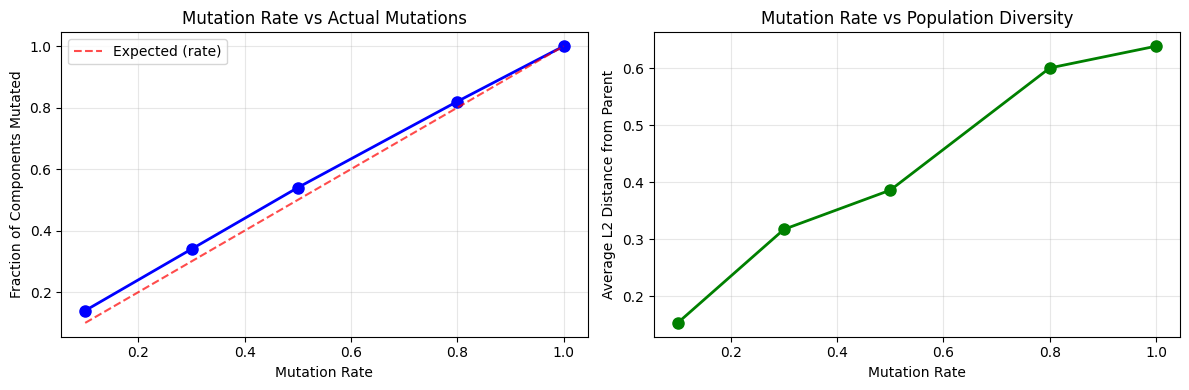

In [88]:
# Visualize mutation rate effects
rates = list(results.keys())
mut_fracs = [results[r]["mutation_fraction"] for r in rates]
avg_dists = [results[r]["avg_distance"] for r in rates]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(rates, mut_fracs, "bo-", linewidth=2, markersize=8)
plt.plot(rates, rates, "r--", alpha=0.7, label="Expected (rate)")
plt.xlabel("Mutation Rate")
plt.ylabel("Fraction of Components Mutated")
plt.title("Mutation Rate vs Actual Mutations")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(rates, avg_dists, "go-", linewidth=2, markersize=8)
plt.xlabel("Mutation Rate")
plt.ylabel("Average L2 Distance from Parent")
plt.title("Mutation Rate vs Population Diversity")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. Injection Mode Mutations

**Injection mode** provides an alternative pattern for high-performance batch processing.
Instead of pre-allocating keys, it uses a single key and splits internally.

In [89]:
# Compare standard vs injection mode
standard_gaussian = GaussianMutation(
    num_offspring=2, mutation_rate=0.5, mutation_strength=0.3, input_length=POP_SIZE
)

injection_gaussian = GaussianMutation_injection(
    num_offspring=2, mutation_rate=0.5, mutation_strength=0.3, input_length=POP_SIZE
)

print("Standard vs Injection Mode:")
print(f"Standard keys per op: {standard_gaussian.num_keys_per_atomic_operation}")
print(f"Injection keys per op: {injection_gaussian.num_keys_per_atomic_operation}")

# Key requirements
standard_keys_needed = standard_gaussian.num_keys(real_pop.genes.values.shape)
injection_keys_needed = injection_gaussian.num_keys(real_pop.genes.values.shape)

print("\nTotal keys needed:")
print(f"Standard: {standard_keys_needed}")
print(f"Injection: {injection_keys_needed}")

Standard vs Injection Mode:
Standard keys per op: 2
Injection keys per op: 2

Total keys needed:
Standard: 40
Injection: 1


In [90]:
# Apply both modes and compare results
key_base = jr.PRNGKey(456)

# Standard mode
key_base, subkey = jr.split(key_base)
standard_keys = jr.split(subkey, standard_keys_needed)
standard_result = standard_gaussian(standard_keys, real_pop, real_config)

# Injection mode
key_base, subkey = jr.split(key_base)
injection_result = injection_gaussian(subkey, real_pop, real_config)  # Single key!

print(f"Standard result size: {len(standard_result)}")
print(f"Injection result size: {len(injection_result)}")

# Compare first offspring
parent = real_pop[0]
standard_offspring = standard_result[0]
injection_offspring = injection_result[0]

print("\nFirst offspring comparison:")
print(f"Parent:     {parent.values}")
print(f"Standard:   {standard_offspring}")
print(f"Injection:  {injection_offspring}")

# They should be different (different random seeds) but similar statistics
std_dist = parent.distance(standard_offspring)
inj_dist = parent.distance(RealGenome.from_tensor(injection_offspring))
print("\nDistances from parent:")
print(f"Standard: {std_dist:.4f}")
print(f"Injection: {inj_dist:.4f}")

Standard result size: 20
Injection result size: 20

First offspring comparison:
Parent:     [-2.7015471  1.9166839 -2.341901   2.6928997 -3.56426  ]
Standard:   RealGenome(values=Array([-3.0917053,  1.9166839, -2.3442376,  2.5261872, -3.56426  ],      dtype=float32), subscriptable=True)
Injection:  [-2.191041   1.9166839 -2.341901   2.6928997 -3.56426  ]

Distances from parent:
Standard: 0.4243
Injection: 0.5105


---
## 5. Autocorrection and Bounds

Mutations can push values outside valid bounds. The `clip=True` option enables autocorrection.

In [91]:
# Create a population near the bounds
tight_config = RealGenomeConfig(shape=(DIMS,), bounds=(-1.0, 1.0))  # Tight bounds
key, subkey = jr.split(key)

# Initialize near upper bound
near_bound_values = jnp.full((POP_SIZE, DIMS), 0.9)  # Close to upper bound
near_bound_pop = RealPopulation(
    genes=RealGenome(values=near_bound_values),
    fitness=jnp.full((POP_SIZE,), jnp.nan),
    config=tight_config,
)

print(f"Population near bounds: {near_bound_pop[0].values}")
print(f"Bounds: {tight_config.bounds}")

Population near bounds: [0.9 0.9 0.9 0.9 0.9]
Bounds: (-1.0, 1.0)


In [92]:
# Compare clipped vs non-clipped mutation
clipped_mut = GaussianMutation(
    num_offspring=1,
    mutation_rate=1.0,
    mutation_strength=0.8,  # Large strength to exceed bounds
    clip=True,
    input_length=POP_SIZE,
)

unclipped_mut = GaussianMutation(
    num_offspring=1, mutation_rate=1.0, mutation_strength=0.8, clip=False, input_length=POP_SIZE
)

# Apply both mutations
key, k1, k2 = jr.split(key, 3)

clipped_keys = jr.split(k1, clipped_mut.num_keys(near_bound_pop.genes.values.shape))

clipped_result = clipped_mut(clipped_keys, near_bound_pop, tight_config)
unclipped_result = unclipped_mut(clipped_keys, near_bound_pop, tight_config)

print("Bounds checking:")
print(f"Valid bounds: {tight_config.bounds}")

for i in range(3):
    parent = near_bound_pop[i]
    clipped_child = clipped_result[i]
    unclipped_child = unclipped_result[i]

    # Check bounds violations
    min_val, max_val = tight_config.bounds
    clipped_valid = jnp.all((clipped_child.values >= min_val) & (clipped_child.values <= max_val))
    unclipped_valid = jnp.all(
        (unclipped_child.values >= min_val) & (unclipped_child.values <= max_val)
    )

    print(f"\nIndividual {i}:")
    print(f"  Parent:     {parent.values}")
    print(f"  Clipped:    {clipped_child.values} (valid: {clipped_valid})")
    print(f"  Unclipped:  {unclipped_child.values} (valid: {unclipped_valid})")

Bounds checking:
Valid bounds: (-1.0, 1.0)

Individual 0:
  Parent:     [0.9 0.9 0.9 0.9 0.9]
  Clipped:    [1.         1.         1.         0.02545542 0.5869688 ] (valid: True)
  Unclipped:  [1.8582186  1.2663112  2.5266347  0.02545542 0.5869688 ] (valid: False)

Individual 1:
  Parent:     [0.9 0.9 0.9 0.9 0.9]
  Clipped:    [1.        0.2807855 1.        0.8281501 1.       ] (valid: True)
  Unclipped:  [1.0545322 0.2807855 1.2647371 0.8281501 1.0977826] (valid: False)

Individual 2:
  Parent:     [0.9 0.9 0.9 0.9 0.9]
  Clipped:    [-0.21267319  1.         -0.07153076  1.          0.95721346] (valid: True)
  Unclipped:  [-0.21267319  1.0082221  -0.07153076  1.9721732   0.95721346] (valid: False)


---
## 6. Performance and JIT Compilation

Mutation operators are JAX PyTrees and fully compatible with `jax.jit`.

In [93]:
# JIT compile mutation operators
gaussian_jit = jax.jit(gaussian_mut)

# Warm-up compilation
test_keys = jr.split(jr.PRNGKey(0), gaussian_mut.num_keys(real_pop.genes.values.shape))
_ = gaussian_jit(test_keys, real_pop, real_config)

print("JIT compilation completed!")

JIT compilation completed!


In [94]:
# Benchmark performance
import time

N_ITERATIONS = 100


def benchmark_mutation(mutator, mutator_jit, name):
    key_bench = jr.PRNGKey(999)

    # Non-JIT
    start = time.perf_counter()
    for _ in range(N_ITERATIONS):
        key_bench, subkey = jr.split(key_bench)
        mut_keys = jr.split(subkey, mutator.num_keys(real_pop.genes.values.shape))
        _ = mutator(mut_keys, real_pop, real_config)
    non_jit_time = time.perf_counter() - start

    # JIT
    key_bench = jr.PRNGKey(999)
    start = time.perf_counter()
    for _ in range(N_ITERATIONS):
        key_bench, subkey = jr.split(key_bench)
        mut_keys = jr.split(subkey, mutator.num_keys(real_pop.genes.values.shape))
        _ = mutator_jit(mut_keys, real_pop, real_config)
    jit_time = time.perf_counter() - start

    speedup = non_jit_time / jit_time
    print(
        f"{name:12}: Non-JIT {non_jit_time * 1000:6.2f}ms | JIT {jit_time * 1000:6.2f}ms | Speedup {speedup:.1f}x"
    )
    return speedup


print(f"Benchmarking {N_ITERATIONS} mutations (population size {POP_SIZE}):")
gaussian_speedup = benchmark_mutation(gaussian_mut, gaussian_jit, "Gaussian")

# Compile and benchmark other mutations
ball_jit = jax.jit(ball_mut)
poly_jit = jax.jit(poly_mut)

# Warm up
ball_keys = jr.split(jr.PRNGKey(0), ball_mut.num_keys(real_pop.genes.values.shape))
poly_keys = jr.split(jr.PRNGKey(0), poly_mut.num_keys(real_pop.genes.values.shape))
_ = ball_jit(ball_keys, real_pop, real_config)
_ = poly_jit(poly_keys, real_pop, real_config)

ball_speedup = benchmark_mutation(ball_mut, ball_jit, "Ball")
poly_speedup = benchmark_mutation(poly_mut, poly_jit, "Polynomial")

Benchmarking 100 mutations (population size 10):
Gaussian    : Non-JIT 761.99ms | JIT  23.12ms | Speedup 33.0x
Ball        : Non-JIT 317.80ms | JIT  10.76ms | Speedup 29.5x
Polynomial  : Non-JIT 299.08ms | JIT  10.94ms | Speedup 27.3x


---
## 7. Custom Mutation Operator

Example of implementing a custom mutation operator following the 3-Tier paradigm.

In [95]:
from typing import Any, cast

import chex
from flax import struct

from malthusjax.operators.base import BaseMutation


@struct.dataclass
class CauchyMutation(BaseMutation[RealGenome, RealGenomeConfig, RealPopulation]):
    """Cauchy mutation: uses Cauchy distribution instead of Gaussian.

    Cauchy has heavier tails than Gaussian, allowing for larger jumps.
    Good for escaping local optima.
    """

    mutation_rate: float = 0.1
    scale: float = 1.0  # Cauchy scale parameter
    clip: bool = struct.field(pytree_node=False, default=True)

    @property
    def num_keys_per_atomic_operation(self) -> int:
        return 2  # mask + Cauchy noise

    def _generate_noise(self, keys: chex.Array, config: RealGenomeConfig) -> chex.Array:
        """Tier 2: Generate Cauchy noise with mask."""
        k_mask, k_cauchy = keys[0], keys[1]

        # Bernoulli mask
        mask_val = jax.random.bernoulli(k_mask, p=self.mutation_rate, shape=config.shape).astype(
            config.dtype
        )

        # Cauchy noise using inverse CDF method
        uniform = jax.random.uniform(k_cauchy, shape=config.shape, dtype=config.dtype)
        # Cauchy quantile function: scale * tan(π * (u - 0.5))
        cauchy_noise = self.scale * jnp.tan(jnp.pi * (uniform - 0.5))

        return cauchy_noise * mask_val

    def _mutate_one(
        self, genome: RealGenome, noise_data: chex.Array, config: RealGenomeConfig, **kwargs: Any
    ) -> RealGenome:
        """Tier 1: Apply noise to genome."""
        mutated_values = genome.values + noise_data

        if self.clip:
            min_val, max_val = config.bounds
            mutated_values = jnp.clip(mutated_values, min_val, max_val)

        return cast(RealGenome, cast(Any, genome).replace(values=mutated_values))

In [96]:
# Test custom Cauchy mutation
cauchy_mut = CauchyMutation(num_offspring=1, mutation_rate=0.5, scale=0.5, input_length=POP_SIZE)

key, subkey = jr.split(key)
cauchy_keys = jr.split(subkey, cauchy_mut.num_keys(real_pop.genes.values.shape))
cauchy_result = cauchy_mut(cauchy_keys, real_pop, real_config)

print("Cauchy mutation applied!")
print(f"Scale parameter: {cauchy_mut.scale}")

# Compare with Gaussian
gaussian_comparable = GaussianMutation(
    num_offspring=2,
    mutation_rate=0.5,
    mutation_strength=0.5,  # Same as Cauchy scale
    input_length=POP_SIZE,
)

key, subkey = jr.split(key)
gauss_keys = jr.split(subkey, gaussian_comparable.num_keys(real_pop.genes.values.shape))
gauss_result = gaussian_comparable(gauss_keys, real_pop, real_config)

print("\nGaussian vs Cauchy mutation comparison:")
parent = real_pop[0]
cauchy_child = cauchy_result[0]
gauss_child = gauss_result[0]

print(f"Parent:   {parent.values}")
print(f"Cauchy:   {cauchy_child.values}")
print(f"Gaussian: {gauss_child.values}")

# Calculate jump distances
cauchy_dist = jnp.sqrt(jnp.sum((cauchy_child.values - parent.values) ** 2))
gauss_dist = jnp.sqrt(jnp.sum((gauss_child.values - parent.values) ** 2))

print("\nJump distances:")
print(f"Cauchy: {cauchy_dist:.4f}")
print(f"Gaussian: {gauss_dist:.4f}")
print("Cauchy typically makes larger jumps due to heavy tails")

Cauchy mutation applied!
Scale parameter: 0.5

Gaussian vs Cauchy mutation comparison:
Parent:   [-2.7015471  1.9166839 -2.341901   2.6928997 -3.56426  ]
Cauchy:   [-3.3707864  1.9166839 -1.8609337  2.6928997 -3.56426  ]
Gaussian: [-2.6488616  1.9166839 -2.677703   2.6928997 -3.56426  ]

Jump distances:
Cauchy: 0.8241
Gaussian: 0.3399
Cauchy typically makes larger jumps due to heavy tails


---
## Summary

### Binary Mutations
| Operator | Key Parameters | Effect | Best For |
|----------|---------------|---------|----------|
| `BitFlipMutation` | `mutation_rate` | Independent bit flips | General binary problems |
| `ScrambleMutation` | `mutation_rate` | Complete permutation | Order-independent problems |
| `SwapMutation` | `mutation_rate` | Two-position swap | Local search, permutations |

### Real-Valued Mutations
| Operator | Key Parameters | Distribution | Best For |
|----------|---------------|-------------|----------|
| `GaussianMutation` | `mutation_rate`, `mutation_strength` | Normal | General continuous optimization |
| `BallMutation` | `radius`, `mutation_rate` | Uniform in sphere | Rotational invariance needed |
| `PolynomialMutation` | `eta`, `mutation_rate` | Polynomial | Genetic algorithm standard |
| `CauchyMutation` (custom) | `scale`, `mutation_rate` | Cauchy (heavy tails) | Escaping local optima |

### Key Architecture Features
- **3-Tier Paradigm**: Separates RNG (Tier 2) from arithmetic (Tier 1) for optimal XLA fusion
- **Batch Processing**: Generates multiple offspring per parent efficiently
- **Key Budgeting**: Pre-calculates PRNG key requirements for memory efficiency
- **Injection Mode**: Alternative pattern using single key with internal splitting
- **Autocorrection**: Optional bounds clipping with `clip=True`
- **JIT Compatible**: Full JAX compilation support for high performance

All operators return **offspring populations** with reset fitness (NaN) ready for evaluation.